In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

sc.settings.verbosity = 1
sc.set_figure_params(dpi=100, frameon=False)
plt.rcParams["figure.figsize"] = (5, 4)

DATA_DIR = "."  # this notebook lives inside scCourse26/, keep all I/O local to this folder
RNA_PATH = f"{DATA_DIR}/rna.h5ad"
PROTEIN_PATH = f"{DATA_DIR}/protein.h5ad"

In [3]:
rna = sc.read_h5ad(RNA_PATH)
protein = sc.read_h5ad(PROTEIN_PATH)

print(rna)
print()
print(protein)

AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'
    layers: None (.X)

AnnData object with n_obs × n_vars = 218331 × 24
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'Target', 'Clone', 'TotalSeq A#', 'Barcode', 'Isotype_control', 'ncounts', 'ncells'
    layers: None (.X)


Both modalities were measured in the same cells (CITE-seq), so `rna` and `protein` should share the
same `obs_names` in the same order. This is checked explicitly before doing anything else, since all
downstream QC/filtering on RNA needs to stay in sync with the protein object.

In [4]:
assert rna.n_obs == protein.n_obs, "RNA and protein have different numbers of cells!"
(rna.obs_names == protein.obs_names).all()

np.True_

## 1. Dataset overview


In [5]:
rna.obs.head()

,library_preparation_protocol,perturbation_2,MOI,sgRNA,UMI_count,guide_id,perturbation,tissue_type,cancer,disease,perturbation_type,celltype,organism,perturbation_type_2,nperts,ngenes,ncounts,percent_mito,percent_ribo
cell_name,,,,,,,,,,,,,,,,,,,
CELL_1,10X 3' v3 sequencing,Control,1,HLA-B_2,10832.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3520,10832.0,3.618907,12.943131
CELL_2,10X 3' v3 sequencing,Control,2,nan,10731.0,NGFR_3;SERPINF1_3,NGFR,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,3531,10731.0,4.864412,12.701519
CELL_3,10X 3' v3 sequencing,Control,1,HLA-B_2,28821.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,5541,28821.0,4.250373,12.348635
CELL_4,10X 3' v3 sequencing,Control,2,nan,15322.0,NMRK1_3;S100A6_3,NMRK1,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,1,4086,15322.0,5.743376,15.272158
CELL_5,10X 3' v3 sequencing,Control,0,nan,10314.0,nan,control,cell_line_co-culture,True,melanoma,CRISPR,melanocytes,human,IFN-γ stimulation,0,3178,10314.0,5.497382,15.105682


- `perturbation_2`: the experimental **condition** (`Control`, `IFNγ`, `Co-culture`)
- `perturbation`: the **target gene** knocked out in that cell (or `control` for non-targeting guides)
- `sgRNA` / `guide_id`: the specific guide RNA(s) detected in the cell
- `MOI`: multiplicity of infection (number of distinct guides detected)
- `nperts`: number of *gene* perturbations assigned to the cell (0 = control/unassigned, 1 = single perturbation)
- `UMI_count`, `ncounts`, `ngenes`: guide-capture UMI count and RNA library size / complexity
- `percent_mito`, `percent_ribo`: mitochondrial / ribosomal RNA content (pre-computed by the data provider)

In [6]:
print("Cells per condition:")
print(rna.obs["perturbation_2"].value_counts())
print()
print("Number of distinct perturbation targets (incl. control):", rna.obs["perturbation"].nunique())
print()
print("nperts (# gene KOs assigned per cell):")
print(rna.obs["nperts"].value_counts())
print()
print("Cells per condition x nperts:")
print(pd.crosstab(rna.obs["perturbation_2"], rna.obs["nperts"]))

Cells per condition:
perturbation_2
IFNγ          87590
Co-culture    73114
Control       57627
Name: count, dtype: int64

Number of distinct perturbation targets (incl. control): 249

nperts (# gene KOs assigned per cell):
nperts
1    160726
0     57605
Name: count, dtype: int64

Cells per condition x nperts:
nperts              0      1
perturbation_2              
Co-culture      18334  54780
Control         15361  42266
IFNγ            23910  63680


In [7]:
rna.var.head()

,ensembl_id,ncounts,ncells
gene_symbol,,,
A1BG,ENSG00000121410,41265.0,34705
A1BG-AS1,ENSG00000268895,13133.0,12463
A1CF,ENSG00000148584,114.0,114
A2M,ENSG00000175899,219.0,193
A2M-AS1,ENSG00000245105,62.0,62


In [8]:
protein.var

,Target,Clone,TotalSeq A#,Barcode,Isotype_control,ncounts,ncells
protein,,,,,,,
CD117,CD117,104D2,61,AGACTAATAGCTGAC,Mouse_IgG1,1958636.0,109844
CD119,CD119,GIR-208,219,TGTGTATTCCCTTGT,Mouse_IgG1,1825992.0,208751
CD140a,CD140A,16A1,128,ATGCGCCGAGAATTA,Mouse_IgG1,689121.0,62317
CD140b,CD140B,18A2,129,CAATGGTTCACTGCC,Mouse_IgG1,322194.0,94374
CD172a,CD172a,15-414,408,CGTGTTTAACTTGAG,Mouse_IgG2a,866783.0,159289
CD184,CD184,12G5,366,TCAGGTCCTTTCAAC,Mouse_IgG2a,6860296.0,133766
CD202b,CD202B,33.1,588,CGATCCCTTACCTAT,Mouse_IgG1,126985.0,72538
CD274,CD274,29.E2.A3,7,GTTGTCCGACAATAC,Mouse_IgG2b,4634427.0,209732
CD29,CD29,TS2/16,369,GTATTCCCTCAGTCA,Mouse_IgG1,37730224.0,218326


## 3. QC metrics (RNA)

The object already ships with `ncounts`, `ngenes`, `percent_mito`, `percent_ribo` in `.obs`. The
the standard scanpy QC metrics are recomputed from `.X` directly (flagging mitochondrial `MT-*` and
ribosomal `RPS*/RPL*` genes) as a sanity check that `.X` indeed holds raw counts consistent with the
provided metadata, and then use scanpy's metrics going forward for consistency with standard scRNA-seq
QC workflows.

In [9]:
rna.var["mt"] = rna.var_names.str.startswith("MT-")
rna.var["ribo"] = rna.var_names.str.startswith(("RPS", "RPL"))
print("n mitochondrial genes:", rna.var["mt"].sum())
print("n ribosomal genes:", rna.var["ribo"].sum())

sc.pp.calculate_qc_metrics(
    rna, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True
)

# sanity check against the metadata columns shipped with the object
print("\nmax abs diff, total_counts vs ncounts:",
      (rna.obs["total_counts"] - rna.obs["ncounts"]).abs().max())
print("max abs diff, n_genes_by_counts vs ngenes:",
      (rna.obs["n_genes_by_counts"] - rna.obs["ngenes"]).abs().max())
print("max abs diff, pct_counts_mt vs percent_mito:",
      (rna.obs["pct_counts_mt"] - rna.obs["percent_mito"]).abs().max())

n mitochondrial genes: 13
n ribosomal genes: 102

max abs diff, total_counts vs ncounts: 0.0
max abs diff, n_genes_by_counts vs ngenes: 0
max abs diff, pct_counts_mt vs percent_mito: 1.6708172729806847e-06


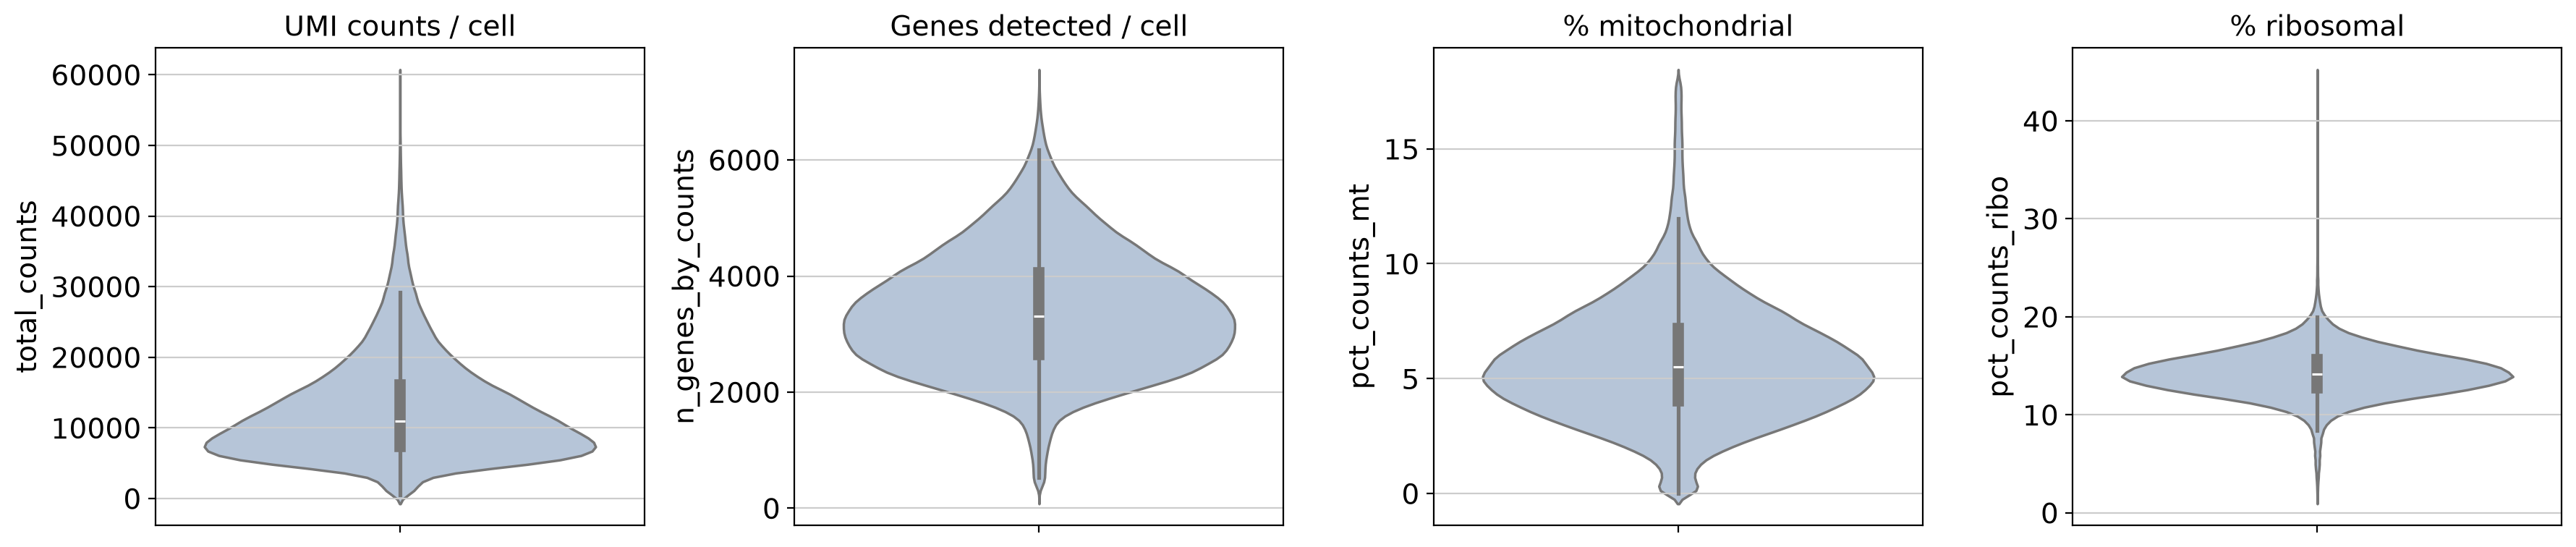

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics = ["total_counts", "n_genes_by_counts", "pct_counts_mt", "pct_counts_ribo"]
titles = ["UMI counts / cell", "Genes detected / cell", "% mitochondrial", "% ribosomal"]
for ax, m, t in zip(axes, metrics, titles):
    sns.violinplot(y=rna.obs[m], ax=ax, inner="box", color="lightsteelblue")
    ax.set_title(t)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

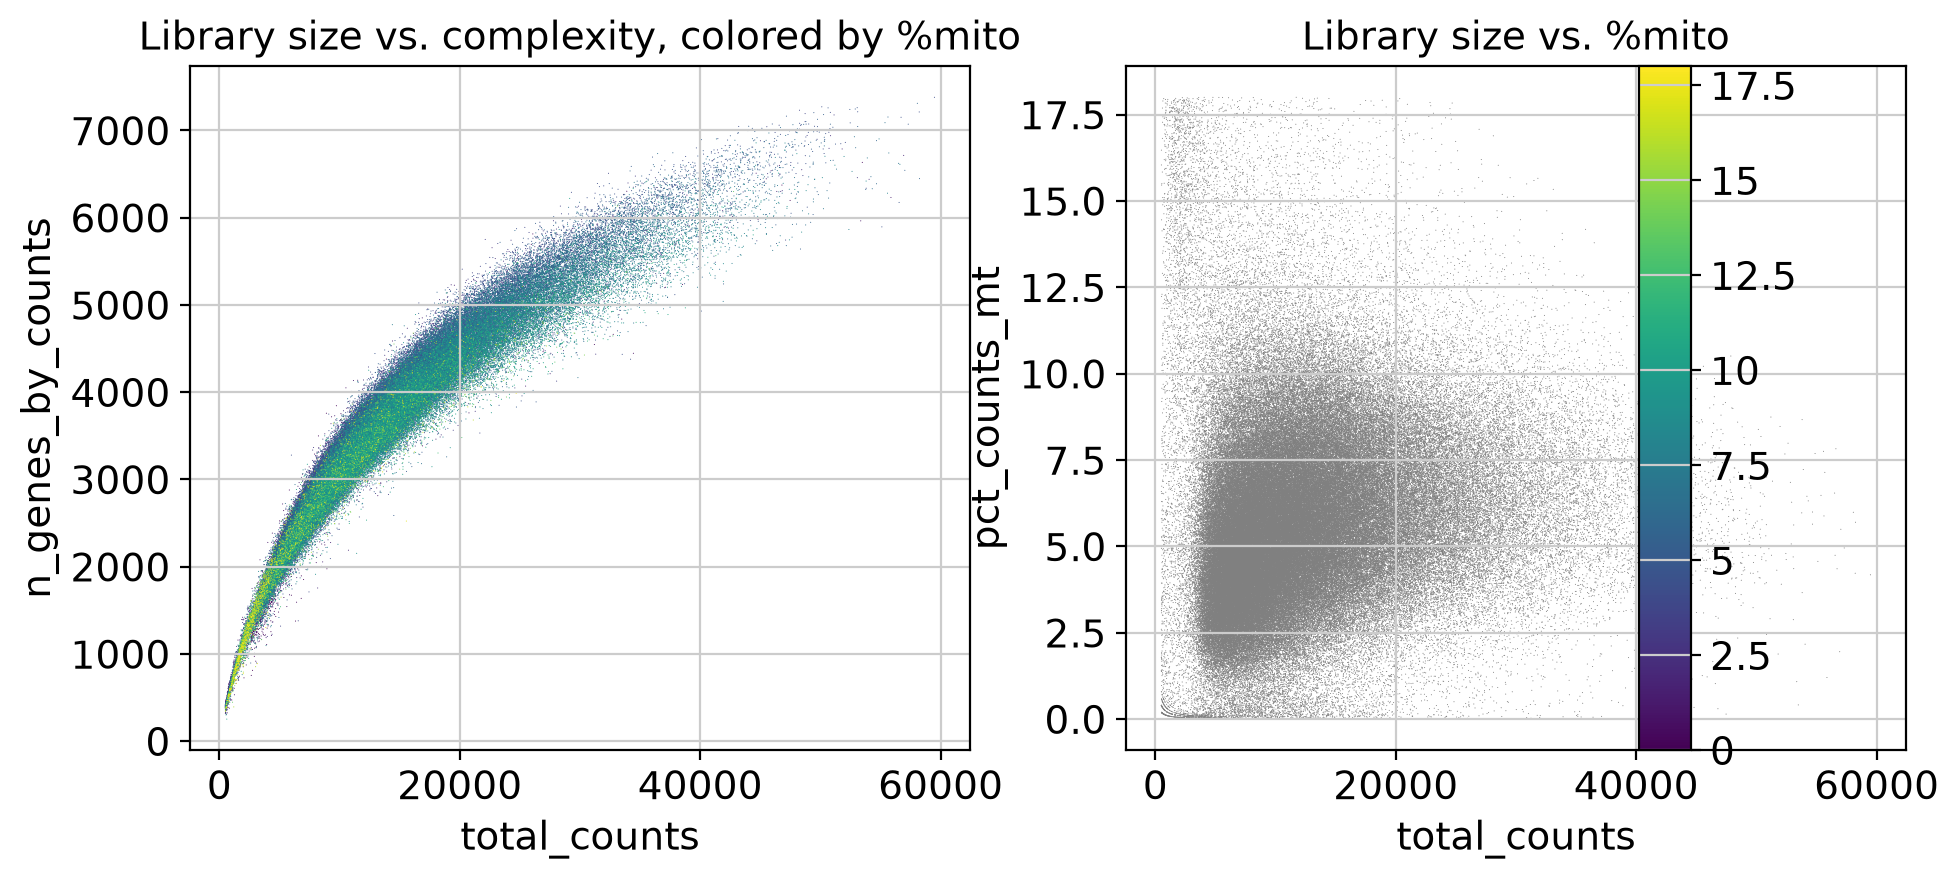

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sc.pl.scatter(rna, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt", ax=axes[0], show=False)
axes[0].set_title("Library size vs. complexity, colored by %mito")

sc.pl.scatter(rna, x="total_counts", y="pct_counts_mt", ax=axes[1], show=False)
axes[1].set_title("Library size vs. %mito")


plt.show()

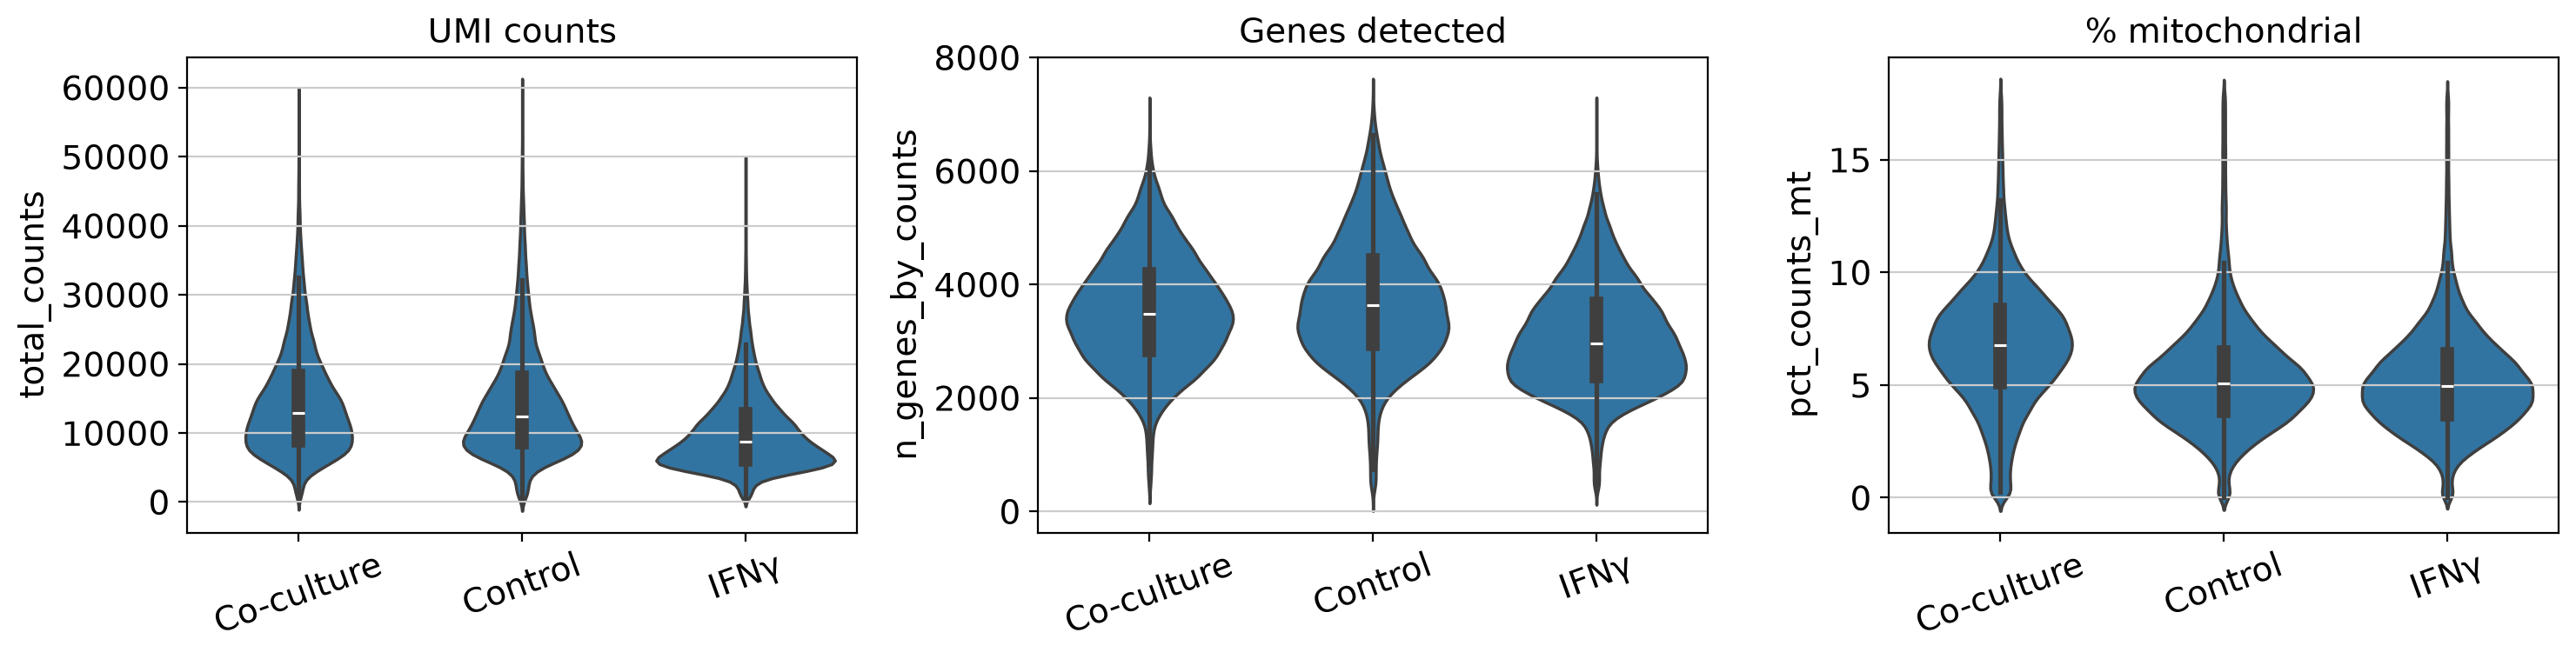

In [12]:
# QC metrics split by condition, to check none of the 3 experimental arms is systematically
# lower quality than the others
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m, t in zip(axes, ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
                     ["UMI counts", "Genes detected", "% mitochondrial"]):
    sns.violinplot(x=rna.obs["perturbation_2"], y=rna.obs[m], ax=ax, inner="box")
    ax.set_title(t)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

**Observations:** The QC metrics look narrow and well-behaved (e.g. `total_counts` ≥ 500, `pct_counts_mt`
≤ ~18%, `pct_counts_ribo` ≤ ~45%): this dataset has already been through an initial round of QC
filtering by the data provider (empty droplets / very low-complexity cells and extreme mito outliers
were already removed). There is no strong difference in QC metrics between the three conditions, so
we can filter thresholds jointly across the whole dataset without biasing any one condition. Filtering will still be done for good practice

## 4. QC-based filtering

- **Cells:** keep cells with ≥ 200 detected genes, ≥ 500 UMI counts, and ≤ 20% mitochondrial reads.
- **Genes:** keep genes detected in ≥ 3 cells

In [13]:
MIN_GENES = 200
MIN_COUNTS = 500
MAX_PCT_MT = 20
MIN_CELLS_PER_GENE = 3

n_obs_before, n_vars_before = rna.shape

keep_cells = (
    (rna.obs["n_genes_by_counts"] >= MIN_GENES)
    & (rna.obs["total_counts"] >= MIN_COUNTS)
    & (rna.obs["pct_counts_mt"] <= MAX_PCT_MT)
)
print(f"Cells passing QC: {keep_cells.sum()} / {rna.n_obs} ({100*keep_cells.mean():.2f}%)")

rna = rna[keep_cells].copy()
sc.pp.filter_genes(rna, min_cells=MIN_CELLS_PER_GENE)

print(f"\nShape before: {n_obs_before} cells x {n_vars_before} genes")
print(f"Shape after:  {rna.n_obs} cells x {rna.n_vars} genes")

Cells passing QC: 218331 / 218331 (100.00%)

Shape before: 218331 cells x 23712 genes
Shape after:  218331 cells x 23711 genes


In [14]:
# keep protein modality in sync with the filtered cell set
protein = protein[rna.obs_names].copy()
assert (rna.obs_names == protein.obs_names).all()
print(protein.shape)

(218331, 24)


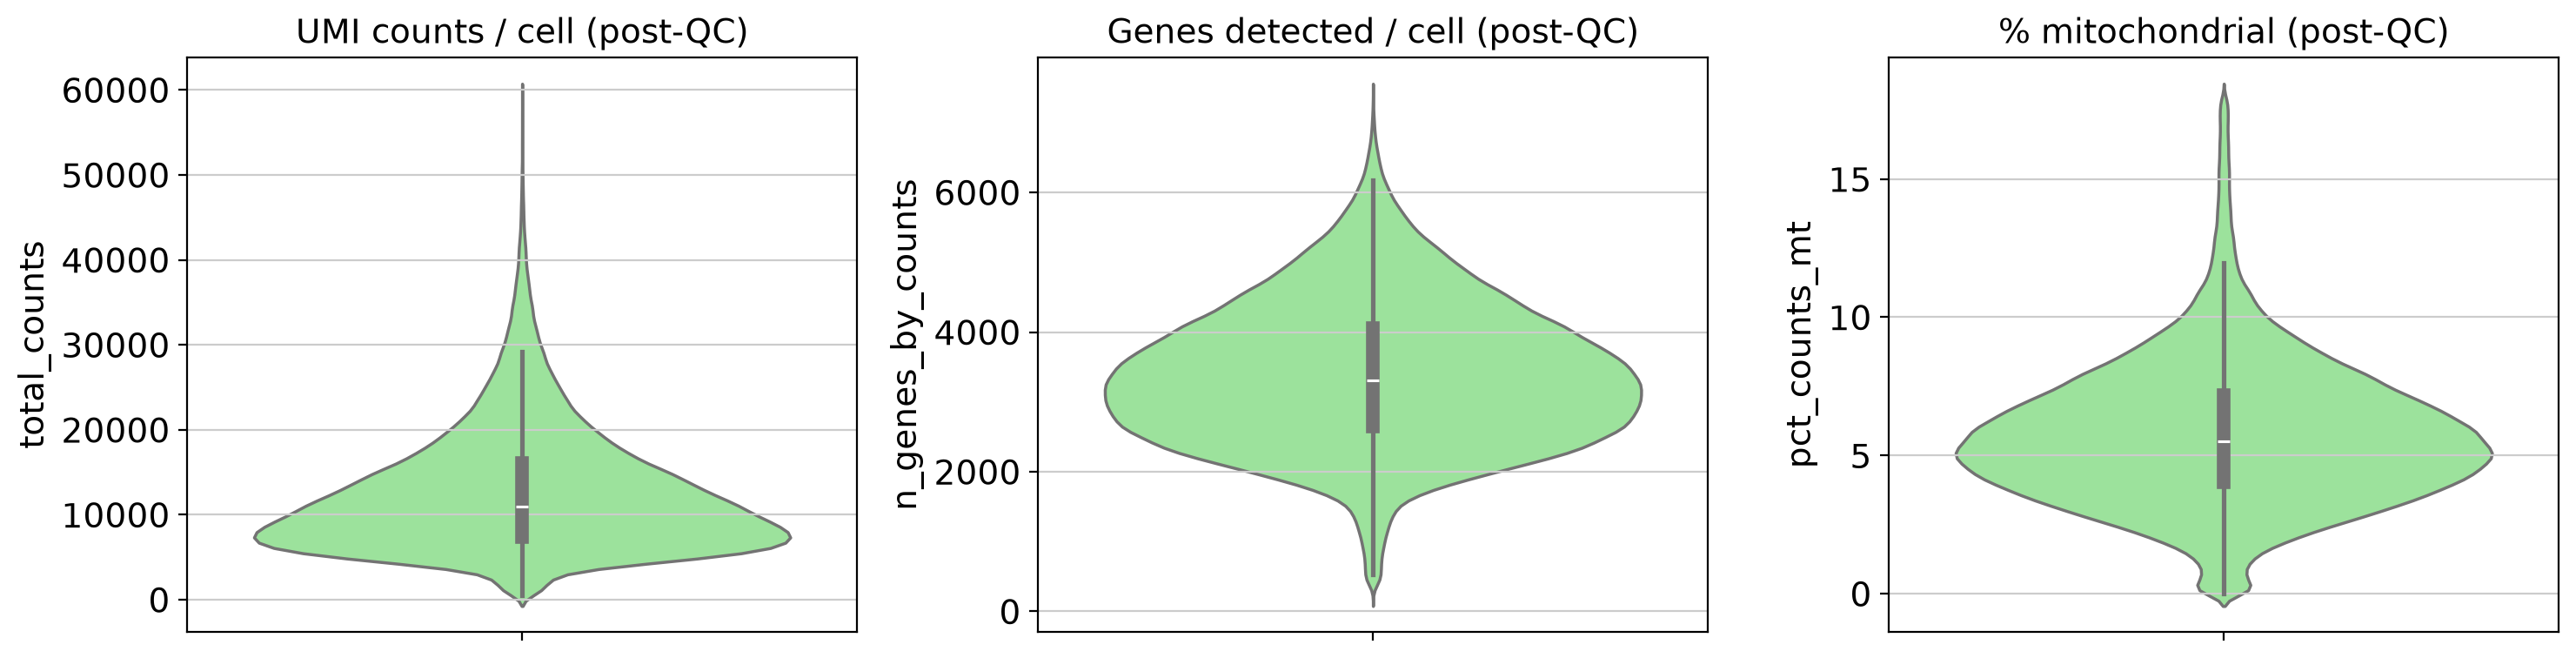

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m, t in zip(axes, ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
                     ["UMI counts / cell", "Genes detected / cell", "% mitochondrial"]):
    sns.violinplot(y=rna.obs[m], ax=ax, inner="box", color="lightgreen")
    ax.set_title(f"{t} (post-QC)")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 6. normalization + embedding

As a final check that the filtered data make biological sense, we run a standard
normalize → log1p → HVG → PCA → UMAP pipeline on the RNA and confirm that (a) cells separate along
expected axes (e.g. the `IFNγ` condition should have a distinct interferon-response signature) and
(b) the embedding is not simply recapitulating QC metrics‚

In [ ]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

sc.pp.highly_variable_genes(rna, n_top_genes=2000, batch_key="perturbation_2")
sc.pp.pca(rna, n_comps=50, mask_var="highly_variable")
sc.pp.neighbors(rna, n_neighbors=15)
sc.tl.umap(rna)

/g/korbel2/shahp/.conda_envs/denbi/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


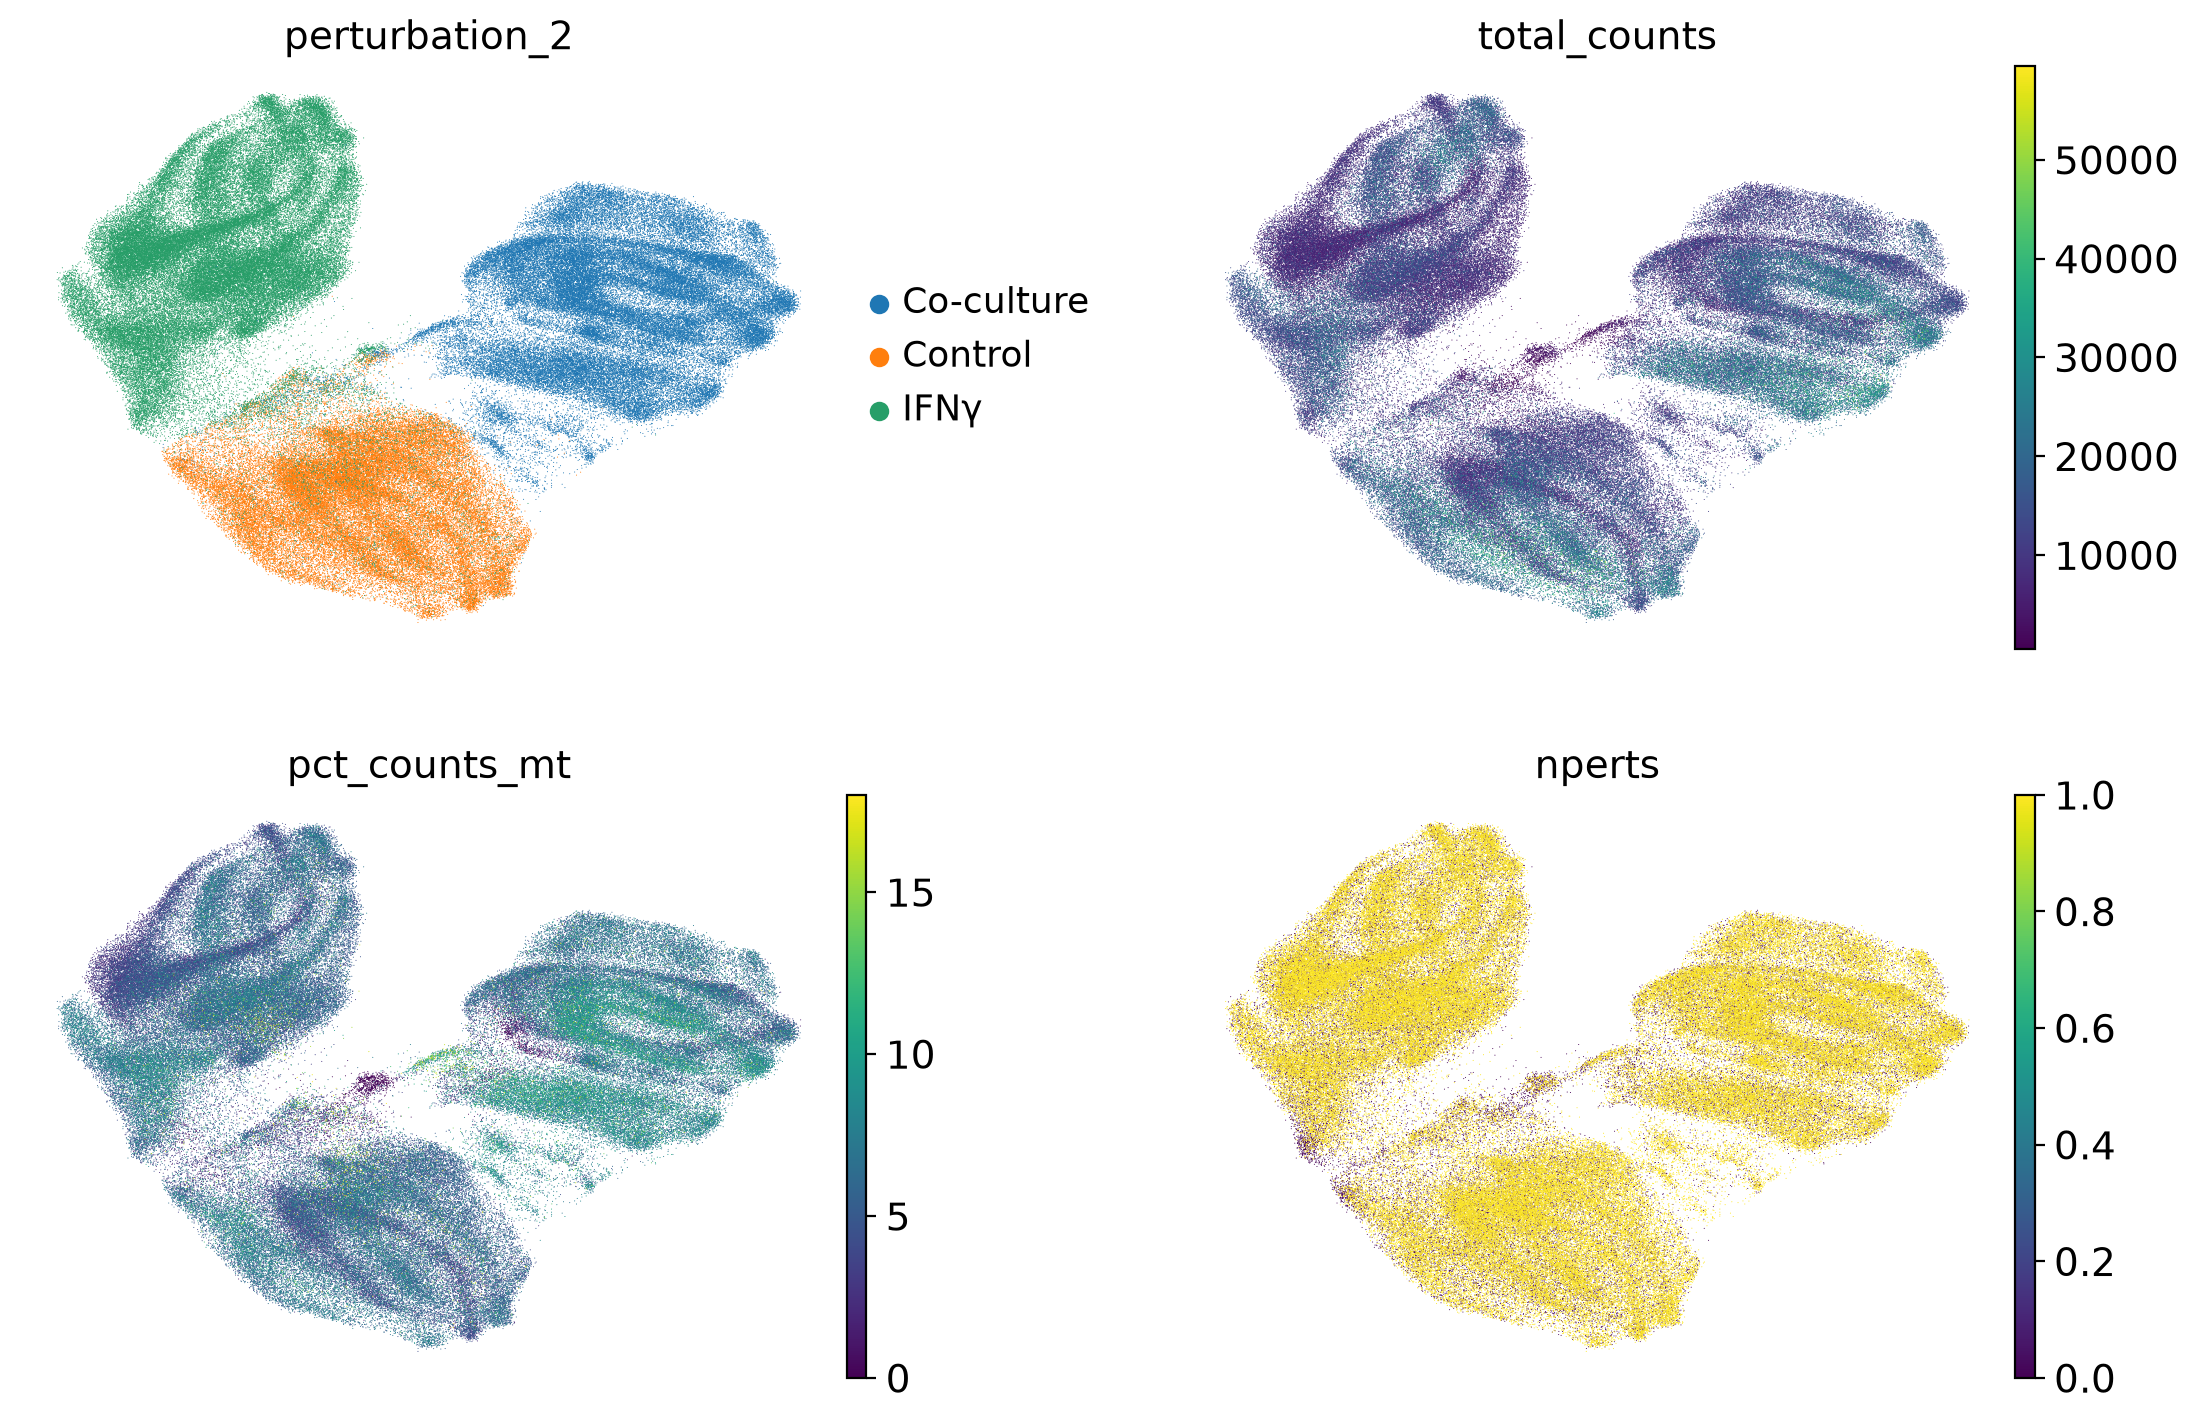

In [ ]:
sc.pl.umap(
    rna,
    color=["perturbation_2", "total_counts", "pct_counts_mt", "nperts"],
    ncols=2,
    wspace=0.3,
)

Cells cluster mainly by `perturbation_2` (biological condition) and not by `total_counts` /
`pct_counts_mt`, that is a good indication that the QC filtering was adequate and that the remaining
structure in the data is driven by biology rather than technical artifacts.

The QC-filtered (but not yet perturbation-analysis-specific) objects are saved back into this folder so
that subsequent notebooks in the seminar project can build on them without repeating the loading/QC
step. `.X` holds normalized/log1p values.

In [30]:
rna.write_h5ad(f"{DATA_DIR}/rna_filtered.h5ad")
protein.write_h5ad(f"{DATA_DIR}/protein_filtered.h5ad")

Saved rna_filtered.h5ad and protein_filtered.h5ad
